In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Project paths
DATASET_PATH = Path("../dataset/raw")

TRAIN_PATH = DATASET_PATH / "train"
VAL_PATH = DATASET_PATH / "val"
TEST_PATH = DATASET_PATH / "test"

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)

Train: ..\dataset\raw\train
Validation: ..\dataset\raw\val
Test: ..\dataset\raw\test


In [3]:
classes = sorted([
    folder.name
    for folder in TRAIN_PATH.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("Classes:")

for i, class_name in enumerate(classes):
    print(i, "->", class_name)

Number of classes: 10
Classes:
0 -> Battery
1 -> Keyboard
2 -> Microwave
3 -> Mobile
4 -> Mouse
5 -> PCB
6 -> Player
7 -> Printer
8 -> Television
9 -> Washing Machine


In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (150, 150)
Batch size: 32


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

print("\nTraining data loaded successfully.")

Found 2400 images belonging to 10 classes.

Training data loaded successfully.


In [6]:
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Validation data loaded successfully.")

Found 300 images belonging to 10 classes.
Validation data loaded successfully.


In [7]:
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Test data loaded successfully.")

Found 300 images belonging to 10 classes.
Test data loaded successfully.


In [8]:
print("Class mapping:")
print(train_generator.class_indices)

Class mapping:
{'Battery': 0, 'Keyboard': 1, 'Microwave': 2, 'Mobile': 3, 'Mouse': 4, 'PCB': 5, 'Player': 6, 'Printer': 7, 'Television': 8, 'Washing Machine': 9}


In [9]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", images.min())
print("Pixel maximum:", images.max())

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32, 10)
Pixel minimum: 0.0
Pixel maximum: 1.0


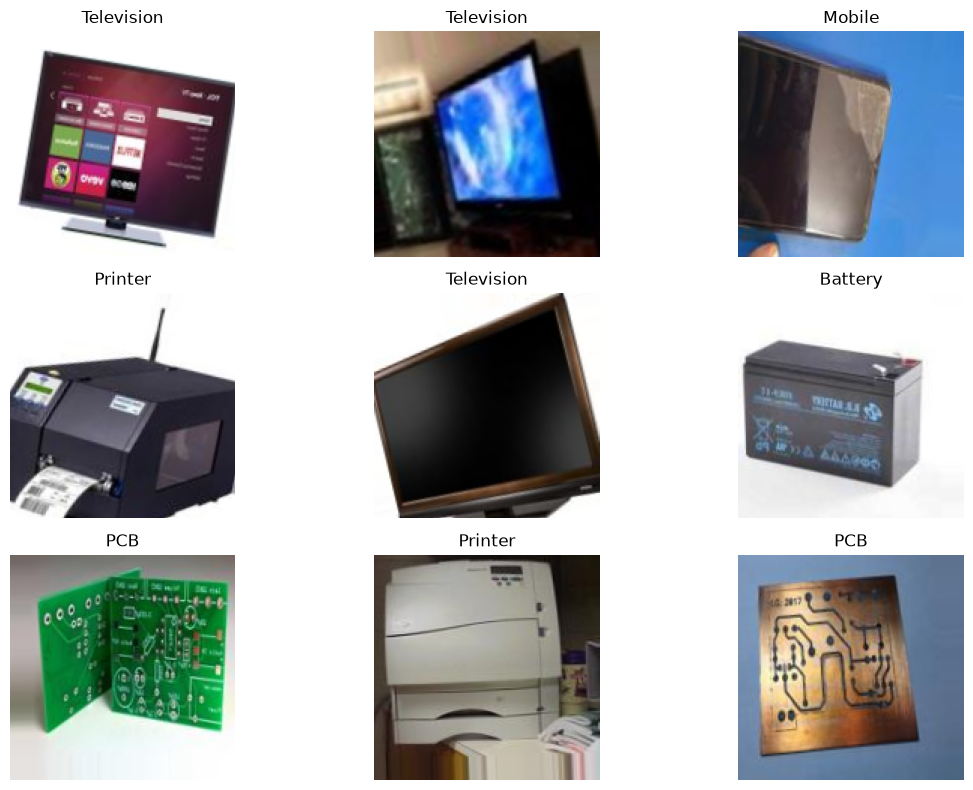

In [10]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    
    class_index = np.argmax(labels[i])
    class_name = list(train_generator.class_indices.keys())[class_index]
    
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
import json

class_names = list(train_generator.class_indices.keys())

with open("../models/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved successfully.")

Class names saved successfully.
